# Régressions — analyses étendues
Ce notebook compare plusieurs approches pour améliorer les performances:
- gestion du déséquilibre pour `higher` (class_weight, sur-échantillonnage)
- comparaison LogisticRegression vs RandomForest
- ajouter `G1` et `G2` pour prédire `G3`
- régression Ridge pour stabiliser les coefficients

In [19]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, classification_report, mean_squared_error, r2_score, confusion_matrix
from sklearn.utils import resample

sns.set(style="whitegrid")
print("CWD:", os.getcwd())
df = pd.read_csv(os.path.join("..", "dataset", "student-mat.csv"))
df.shape

CWD: c:\Users\HKHD\OneDrive\Desktop\Cours\SY09\Projet SY09\notebooks


(395, 33)

In [20]:
# Variables de base (même que reg lin.py)
features = [
    "Medu",
    "Fedu",
    "failures",
    "sex",
    "internet",
    "famsup",
    "studytime",
    "Dalc",
    "Walc",
    "goout"
]
df_encoded = df.copy()
binary_map = {
    "yes": 1,
    "no": 0,
    "F": 0,
    "M": 1
}
for col in ["sex", "internet", "famsup"]:
    df_encoded[col] = df_encoded[col].map(binary_map)

# Préparer X_scaled commun
X_base = df_encoded[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_base)

print('Préparation terminée — df shape:', df.shape)

Préparation terminée — df shape: (395, 33)


higher
1    375
0     20
Name: count, dtype: int64


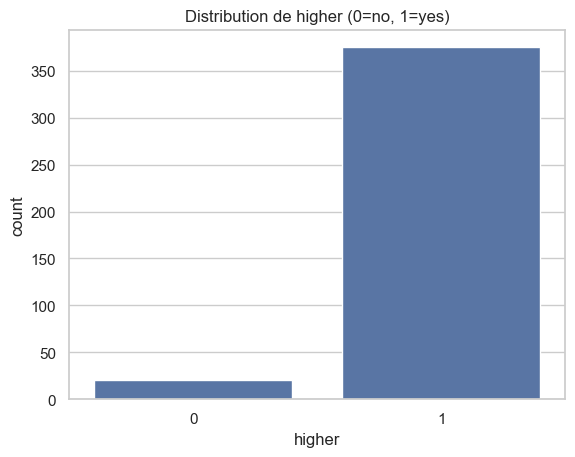

In [21]:
# Distribution de la target 'higher'
y_higher = df_encoded['higher'].map(binary_map)
print(y_higher.value_counts())
sns.countplot(x=y_higher)
plt.title('Distribution de higher (0=no, 1=yes)')
plt.show()

In [22]:
def evaluate_clf(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else None
    res = {}
    res['accuracy'] = accuracy_score(y_test, y_pred)
    res['balanced_accuracy'] = balanced_accuracy_score(y_test, y_pred)
    res['f1'] = f1_score(y_test, y_pred)
    res['report'] = classification_report(y_test, y_pred, zero_division=0)
    if y_prob is not None:
        res['roc_auc'] = roc_auc_score(y_test, y_prob)
    res['confusion'] = confusion_matrix(y_test, y_pred)
    return res

## 1) LogisticRegression — stratégies pour le déséquilibre

In [23]:
# Split de base
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_higher, test_size=0.3, random_state=42, stratify=y_higher
)

# 1. Baseline
log_baseline = LogisticRegression(max_iter=500)
res_baseline = evaluate_clf(log_baseline, X_train, X_test, y_train, y_test)
print('Baseline')
print(res_baseline)

# 2. Class_weight='balanced'
log_bal = LogisticRegression(max_iter=500, class_weight='balanced')
res_bal = evaluate_clf(log_bal, X_train, X_test, y_train, y_test)
print('\nClass_weight=balanced')
print(res_bal)

# 3. Sur-échantillonnage (upsample minority) sur le training set
train_df = pd.DataFrame(X_train, columns=features)
train_df['target'] = y_train.values
major = train_df[train_df['target'] == 1]
minor = train_df[train_df['target'] == 0]
minor_upsampled = resample(
    minor, replace=True, n_samples=len(major), random_state=42
)
train_up = pd.concat([major, minor_upsampled])
X_train_up = train_up[features].values
y_train_up = train_up['target'].values
log_up = LogisticRegression(max_iter=500)
res_up = evaluate_clf(log_up, X_train_up, X_test, y_train_up, y_test)
print('\nUpsampled')
print(res_up)

Baseline
{'accuracy': 0.9495798319327731, 'balanced_accuracy': 0.5, 'f1': 0.9741379310344828, 'report': '              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00         6\n           1       0.95      1.00      0.97       113\n\n    accuracy                           0.95       119\n   macro avg       0.47      0.50      0.49       119\nweighted avg       0.90      0.95      0.93       119\n', 'roc_auc': 0.8215339233038348, 'confusion': array([[  0,   6],
       [  0, 113]])}

Class_weight=balanced
{'accuracy': 0.7815126050420168, 'balanced_accuracy': 0.806047197640118, 'f1': 0.8712871287128713, 'report': '              precision    recall  f1-score   support\n\n           0       0.17      0.83      0.28         6\n           1       0.99      0.78      0.87       113\n\n    accuracy                           0.78       119\n   macro avg       0.58      0.81      0.57       119\nweighted avg       0.95      0.78      0.84       119\n', 'roc


RandomForest (class_weight=balanced)
{'accuracy': 0.9495798319327731, 'balanced_accuracy': 0.5, 'f1': 0.9741379310344828, 'report': '              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00         6\n           1       0.95      1.00      0.97       113\n\n    accuracy                           0.95       119\n   macro avg       0.47      0.50      0.49       119\nweighted avg       0.90      0.95      0.93       119\n', 'roc_auc': 0.7986725663716815, 'confusion': array([[  0,   6],
       [  0, 113]])}


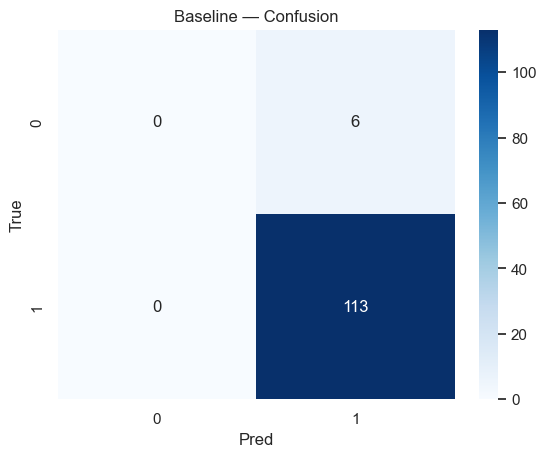

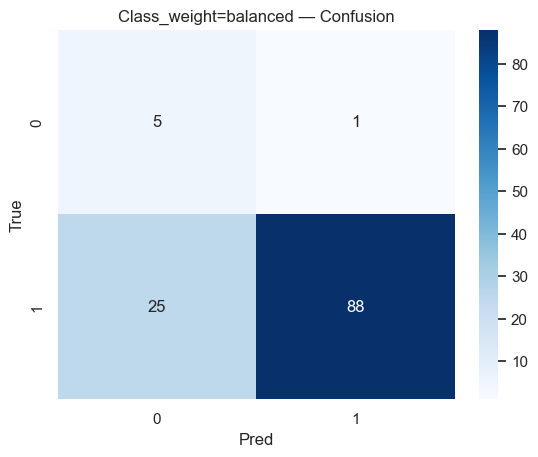

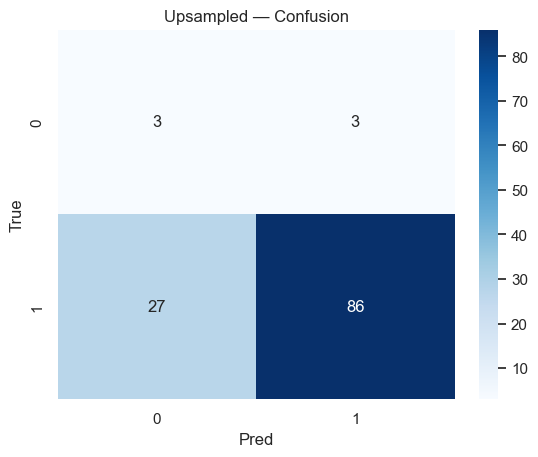

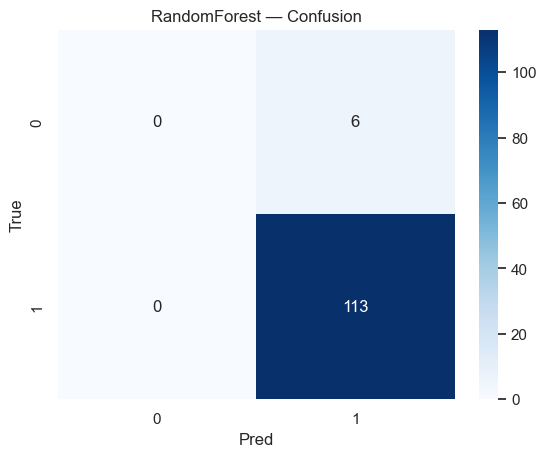

In [24]:
# 4. RandomForest pour comparer
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
res_rf = evaluate_clf(rf, X_train, X_test, y_train, y_test)
print('\nRandomForest (class_weight=balanced)')
print(res_rf)

# Afficher matrices de confusion rapidement
import matplotlib.pyplot as plt
def plot_cm(cm, title='Confusion matrix'):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Pred')
    plt.ylabel('True')
    plt.show()

plot_cm(res_baseline['confusion'], 'Baseline — Confusion')
plot_cm(res_bal['confusion'], 'Class_weight=balanced — Confusion')
plot_cm(res_up['confusion'], 'Upsampled — Confusion')
plot_cm(res_rf['confusion'], 'RandomForest — Confusion')

## 2) Régression linéaire — inclure `G1` et `G2` et comparer Ridge

LinearRegression — R2: 0.797634046904069 RMSE: 2.1091280695369132
RidgeCV — alpha: 1.0 R2: 0.7977538089942345 RMSE: 2.108503876175698
     Variable  LinearCoef  RidgeCoef    AbsLin
11         G2    3.659150   3.621876  3.659150
10         G1    0.570237   0.597870  0.570237
2    failures   -0.295917  -0.297885  0.295917
1        Fedu   -0.208394  -0.209595  0.208394
5      famsup    0.166852   0.165472  0.166852
9       goout    0.125791   0.121824  0.125791
6   studytime   -0.119423  -0.119547  0.119423
7        Dalc   -0.109936  -0.109280  0.109936
0        Medu    0.106337   0.107536  0.106337
8        Walc    0.102658   0.104344  0.102658
4    internet   -0.038162  -0.035049  0.038162
3         sex    0.011724   0.011399  0.011724


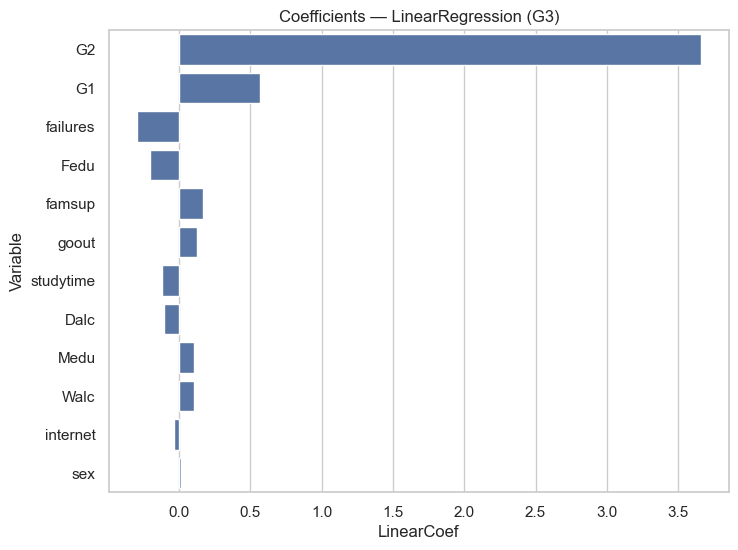

In [25]:
# Ajouter G1 et G2 aux features pour predire G3
features_plus = features + ['G1', 'G2'] if 'G1' in df.columns and 'G2' in df.columns else features
df_lin = df_encoded.copy()
# si G1/G2 existent, garder leurs valeurs brutes
X_lin = df_lin[features_plus]
scaler_lin = StandardScaler()
X_lin_scaled = scaler_lin.fit_transform(X_lin)
y_g3 = df['G3']
Xtr, Xte, ytr, yte = train_test_split(X_lin_scaled, y_g3, test_size=0.3, random_state=42)
# LinearRegression
lr = LinearRegression()
lr.fit(Xtr, ytr)
yp = lr.predict(Xte)
print('LinearRegression — R2:', r2_score(yte, yp), 'RMSE:', np.sqrt(mean_squared_error(yte, yp)))
# RidgeCV
alphas = [0.1, 1.0, 10.0, 100.0]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(Xtr, ytr)
yr = ridge.predict(Xte)
print('RidgeCV — alpha:', ridge.alpha_, 'R2:', r2_score(yte, yr), 'RMSE:', np.sqrt(mean_squared_error(yte, yr)))

coef_df = pd.DataFrame({'Variable': features_plus, 'LinearCoef': lr.coef_, 'RidgeCoef': ridge.coef_})
coef_df['AbsLin'] = coef_df['LinearCoef'].abs()
coef_df = coef_df.sort_values(by='AbsLin', ascending=False)
print(coef_df)
plt.figure(figsize=(8,6))
sns.barplot(data=coef_df, x='LinearCoef', y='Variable')
plt.title('Coefficients — LinearRegression (G3)')
plt.show()

## 3) Classification binaire globale pour G3 et absences
Pour rapporter F1-score, balanced accuracy et ROC AUC, les cibles continues `G3` et `absences` sont binarisées par rapport à leur médiane.

# Binarisation des cibles continues

In [26]:
# Binarisation des cibles continues

def binarize_by_median(series):
    threshold = series.median()
    result = (series > threshold).astype(int)
    print(f"{series.name} median = {threshold}, distribution:\n", result.value_counts(normalize=True))
    return result

# Cibles binaires globales

y_g3_bin = binarize_by_median(df['G3'])
y_abs_bin = binarize_by_median(df['absences'])

y_internet = df_encoded['internet']
y_romantic = df['romantic'].map(binary_map)
y_paid = df['paid'].map(binary_map)

binary_targets = {
    'G3_high': y_g3_bin,
    'absences_high': y_abs_bin,
    'internet': y_internet,
    'romantic': y_romantic,
    'paid': y_paid,
}

feature_cols = [
    'Medu', 'Fedu', 'failures', 'sex', 'internet', 'famsup',
    'studytime', 'Dalc', 'Walc', 'goout'
]
X_bin = df_encoded[feature_cols]
scaler_bin = StandardScaler()
X_bin_scaled = scaler_bin.fit_transform(X_bin)

results_global = []

for target_name, y_target in binary_targets.items():
    print('\n' + '='*70)
    print(f'Target: {target_name}')
    print('='*70)

    X_train, X_test, y_train, y_test = train_test_split(
        X_bin_scaled, y_target, test_size=0.3, random_state=42, stratify=y_target
    )

    clf = LogisticRegression(max_iter=500, class_weight='balanced')
    res = evaluate_clf(clf, X_train, X_test, y_train, y_test)

    results_global.append({
        'target': target_name,
        'accuracy': res['accuracy'],
        'balanced_accuracy': res['balanced_accuracy'],
        'f1': res['f1'],
        'roc_auc': res.get('roc_auc', np.nan),
    })

results_global_df = pd.DataFrame(results_global)
print('\nGlobal binary classification results:')
print(results_global_df)


G3 median = 11.0, distribution:
 G3
0    0.589873
1    0.410127
Name: proportion, dtype: float64
absences median = 4.0, distribution:
 absences
0    0.617722
1    0.382278
Name: proportion, dtype: float64

Target: G3_high

Target: absences_high

Target: internet

Target: romantic

Target: paid

Global binary classification results:
          target  accuracy  balanced_accuracy        f1   roc_auc
0        G3_high  0.596639           0.608163  0.578947  0.673324
1  absences_high  0.563025           0.522372  0.380952  0.529129
2       internet  1.000000           1.000000  1.000000  1.000000
3       romantic  0.529412           0.540665  0.450980  0.533228
4           paid  0.647059           0.651420  0.650000  0.754119


In [27]:
# Binarisation des cibles continues

def binarize_by_median(series):
    threshold = series.median()
    result = (series > threshold).astype(int)
    print(f"{series.name} median = {threshold}, distribution:\n", result.value_counts(normalize=True))
    return result

# Cibles binaires globales

y_g3_bin = binarize_by_median(df['G3'])
y_abs_bin = binarize_by_median(df['absences'])

y_internet = df_encoded['internet']
y_romantic = df['romantic'].map(binary_map)
y_paid = df['paid'].map(binary_map)

binary_targets = {
    'G3_high': y_g3_bin,
    'absences_high': y_abs_bin,
    'internet': y_internet,
    'romantic': y_romantic,
    'paid': y_paid,
}

feature_cols = [
    'Medu', 'Fedu', 'failures', 'sex', 'internet', 'famsup',
    'studytime', 'Dalc', 'Walc', 'goout'
]
X_bin = df_encoded[feature_cols]
scaler_bin = StandardScaler()
X_bin_scaled = scaler_bin.fit_transform(X_bin)

G3 median = 11.0, distribution:
 G3
0    0.589873
1    0.410127
Name: proportion, dtype: float64
absences median = 4.0, distribution:
 absences
0    0.617722
1    0.382278
Name: proportion, dtype: float64


In [28]:
results_global = []

for target_name, y_target in binary_targets.items():
    print('\n' + '='*70)
    print(f'Target: {target_name}')
    print('='*70)

    X_train, X_test, y_train, y_test = train_test_split(
        X_bin_scaled, y_target, test_size=0.3, random_state=42, stratify=y_target
    )

    clf = LogisticRegression(max_iter=500, class_weight='balanced')
    res = evaluate_clf(clf, X_train, X_test, y_train, y_test)

    results_global.append({
        'target': target_name,
        'accuracy': res['accuracy'],
        'balanced_accuracy': res['balanced_accuracy'],
        'f1': res['f1'],
        'roc_auc': res.get('roc_auc', np.nan),
    })

results_global_df = pd.DataFrame(results_global)
print('\nGlobal binary classification results:')
print(results_global_df)


Target: G3_high

Target: absences_high

Target: internet

Target: romantic

Target: paid

Global binary classification results:
          target  accuracy  balanced_accuracy        f1   roc_auc
0        G3_high  0.596639           0.608163  0.578947  0.673324
1  absences_high  0.563025           0.522372  0.380952  0.529129
2       internet  1.000000           1.000000  1.000000  1.000000
3       romantic  0.529412           0.540665  0.450980  0.533228
4           paid  0.647059           0.651420  0.650000  0.754119


## 4) Clustering et classification par cluster
Les clusters sont construits avec une ACP sur toutes les variables sauf `G3`, puis KMeans. Chaque cluster est ensuite évalué séparément.

In [29]:
# Clustering
X_cluster = pd.get_dummies(df.drop(columns=['G3']), drop_first=True)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

pca = PCA(n_components=0.8, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_pca)
df['cluster'] = clusters
print('Cluster sizes:')
print(df['cluster'].value_counts())

c:\Users\HKHD\anaconda3\envs\sy09\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Cluster sizes:
cluster
0    134
2    120
1     71
3     70
Name: count, dtype: int64


In [30]:
cluster_results = []
cluster_regression = []

for cluster_id in sorted(df['cluster'].unique()):
    print('\n' + '#' * 70)
    print(f'Cluster {cluster_id}')
    print('#' * 70)

    df_cluster = df[df['cluster'] == cluster_id].copy()
    df_cluster_encoded = df_cluster.copy()
    for col in ['sex', 'internet', 'famsup', 'higher', 'paid', 'romantic']:
        if col in df_cluster_encoded.columns:
            df_cluster_encoded[col] = df_cluster_encoded[col].map(binary_map)

    X_cluster_features = df_cluster_encoded[feature_cols]
    scaler_local = StandardScaler()
    X_cluster_scaled_local = scaler_local.fit_transform(X_cluster_features)

    # Targets binaires
    targets_cluster = {
        'internet': df_cluster_encoded['internet'],
        'romantic': df_cluster_encoded['romantic'],
        'paid': df_cluster_encoded['paid'],
        'G3_high': binarize_by_median(df_cluster['G3']),
        'absences_high': binarize_by_median(df_cluster['absences']),
    }

    for target_name, y_cluster in targets_cluster.items():
        print('\n' + '-' * 60)
        print(f'Target: {target_name}')
        print('-' * 60)

        if y_cluster.nunique() < 2:
            print('Constant target in this cluster; skipping.')
            continue

        counts = y_cluster.value_counts(normalize=True)
        print('Distribution:\n', counts)
        if counts.min() < 0.15 or len(y_cluster) < 10:
            print('⚠️ Classe trop déséquilibrée ou effectif trop faible — analyse ignorée')
            continue

        X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
            X_cluster_scaled_local,
            y_cluster,
            test_size=0.3,
            random_state=42,
            stratify=y_cluster,
        )

        clf = LogisticRegression(max_iter=500, class_weight='balanced')
        res = evaluate_clf(clf, X_train_c, X_test_c, y_train_c, y_test_c)
        cluster_results.append({
            'cluster': cluster_id,
            'target': target_name,
            'accuracy': res['accuracy'],
            'balanced_accuracy': res['balanced_accuracy'],
            'f1': res['f1'],
            'roc_auc': res.get('roc_auc', np.nan),
        })

    # Régressions continues par cluster pour G3 et absences
    if len(df_cluster) >= 10:
        for cont_target in ['G3', 'absences']:
            y_cont = df_cluster[cont_target]
            X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
                X_cluster_scaled_local, y_cont, test_size=0.3, random_state=42
            )
            lr_r = LinearRegression()
            lr_r.fit(X_train_r, y_train_r)
            y_pred_r = lr_r.predict(X_test_r)
            cluster_regression.append({
                'cluster': cluster_id,
                'target': cont_target,
                'r2': r2_score(y_test_r, y_pred_r),
                'rmse': np.sqrt(mean_squared_error(y_test_r, y_pred_r)),
            })

cluster_results_df = pd.DataFrame(cluster_results)
cluster_regression_df = pd.DataFrame(cluster_regression)
print('\nCluster classification results:')
print(cluster_results_df)
print('\nCluster regression results:')
print(cluster_regression_df)


######################################################################
Cluster 0
######################################################################
G3 median = 10.0, distribution:
 G3
0    0.529851
1    0.470149
Name: proportion, dtype: float64
absences median = 4.0, distribution:
 absences
0    0.626866
1    0.373134
Name: proportion, dtype: float64

------------------------------------------------------------
Target: internet
------------------------------------------------------------
Distribution:
 internet
1    0.761194
0    0.238806
Name: proportion, dtype: float64

------------------------------------------------------------
Target: romantic
------------------------------------------------------------
Distribution:
 romantic
0    0.69403
1    0.30597
Name: proportion, dtype: float64

------------------------------------------------------------
Target: paid
------------------------------------------------------------
Distribution:
 paid
0    0.574627
1    0.425373
Name: prop

---
Résultats complétés avec :
- classification globale binaire pour `G3`, `absences`, `internet`, `romantic`, `paid`;
- classification par cluster pour les mêmes cibles;
- régressions continues par cluster pour `G3` et `absences`.